<a href="https://colab.research.google.com/github/beyza-ozdemir/yolo-object-detection-and-people-counting/blob/main/YOLO_ile_Nesne_Tespiti_(Object_Detection).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt
from skimage import data

Bulunan yüz sayısı: 1


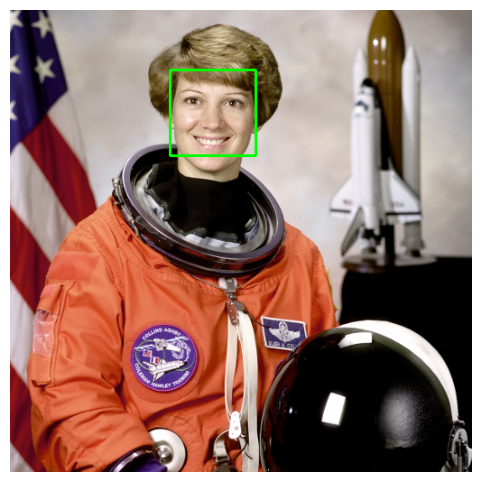

In [4]:
# 1. Hazır fotoğrafı al
img = data.astronaut()

# 2. RGB → BGR
# OpenCV görüntüleri BGR formatında kullanır
img = cv.cvtColor(img, cv.COLOR_RGB2BGR)

# 3. Haar Cascade yüz tespit modelini yükle
haar_cascade = cv.CascadeClassifier(
    cv.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# 4. Görüntüyü gri tona çevir
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 5. Yüzleri bul
faces = haar_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=4
)

# 6. Bulunan yüz sayısını yazdır
print("Bulunan yüz sayısı:", len(faces))

# 7. Yüzlerin etrafına çerçeve çiz
for (x, y, w, h) in faces:
    cv.rectangle(
        img,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

# 8. BGR → RGB
# Matplotlib doğru renk gösterebilsin diye
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 9. Sonucu göster
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [5]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 6.8 MB/s eta 0:00:00


In [12]:
from ultralytics import YOLO
import cv2 as cv
import matplotlib.pyplot as plt
from skimage import data



0: 640x640 1 person, 1 sports ball, 205.2ms
Speed: 10.0ms preprocess, 205.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


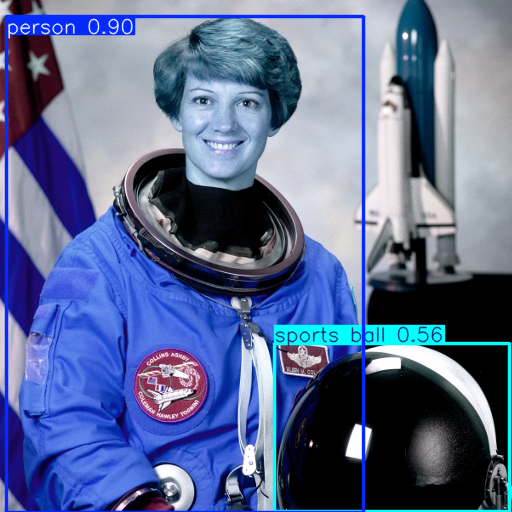

In [16]:
model = YOLO("yolo11n.pt")
img = data.astronaut()
results = model(img)


results[0].show()


0: 448x640 1 cup, 1 dining table, 137.1ms
Speed: 5.5ms preprocess, 137.1ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


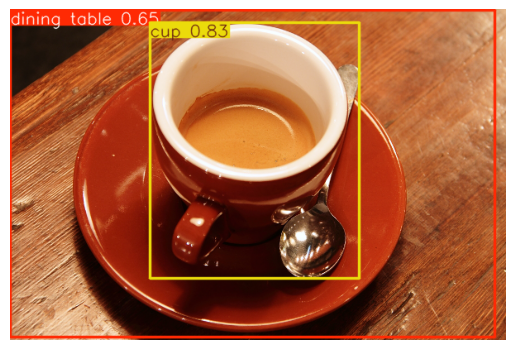

In [21]:
img = data.coffee()
results=model(img)

annotated_img = results[0].plot()
plt.imshow(annotated_img)
plt.axis("off")
plt.show()


In [24]:
for result in results:
    print(result.boxes)

for result in results:
    for cls in result.boxes.cls:
        print(model.names[int(cls)])

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([41., 60.])
conf: tensor([0.8300, 0.6512])
data: tensor([[1.6997e+02, 1.6986e+01, 4.2206e+02, 3.2549e+02, 8.3005e-01, 4.1000e+01],
        [4.1142e-02, 1.6031e+00, 5.8687e+02, 3.9666e+02, 6.5124e-01, 6.0000e+01]])
id: None
is_track: False
orig_shape: (400, 600)
shape: torch.Size([2, 6])
xywh: tensor([[296.0128, 171.2402, 252.0868, 308.5078],
        [293.4543, 199.1294, 586.8264, 395.0526]])
xywhn: tensor([[0.4934, 0.4281, 0.4201, 0.7713],
        [0.4891, 0.4978, 0.9780, 0.9876]])
xyxy: tensor([[1.6997e+02, 1.6986e+01, 4.2206e+02, 3.2549e+02],
        [4.1142e-02, 1.6031e+00, 5.8687e+02, 3.9666e+02]])
xyxyn: tensor([[2.8328e-01, 4.2466e-02, 7.0343e-01, 8.1374e-01],
        [6.8569e-05, 4.0077e-03, 9.7811e-01, 9.9164e-01]])
cup
dining table


In [30]:
for conf in result.boxes.conf:
  print(float(conf))

0.8300456404685974
0.6512416005134583


In [27]:
threshold = 0.70

for result in results:
    for cls, conf in zip(result.boxes.cls, result.boxes.conf):

        if conf >= threshold:
            name = model.names[int(cls)]
            print(f"{name} → %{float(conf) * 100:.1f}")

cup → %83.0



0: 640x640 1 person, 267.8ms
Speed: 7.4ms preprocess, 267.8ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


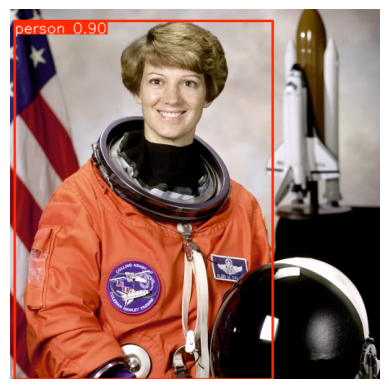

In [28]:
from ultralytics import YOLO
from skimage import data
import matplotlib.pyplot as plt

model = YOLO("yolo11n.pt")

img = data.astronaut()

results = model(img, conf=0.70)

annotated_img = results[0].plot()

plt.imshow(annotated_img)
plt.axis("off")
plt.show()


0: 640x480 4 persons, 1 bus, 170.2ms
Speed: 6.8ms preprocess, 170.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)


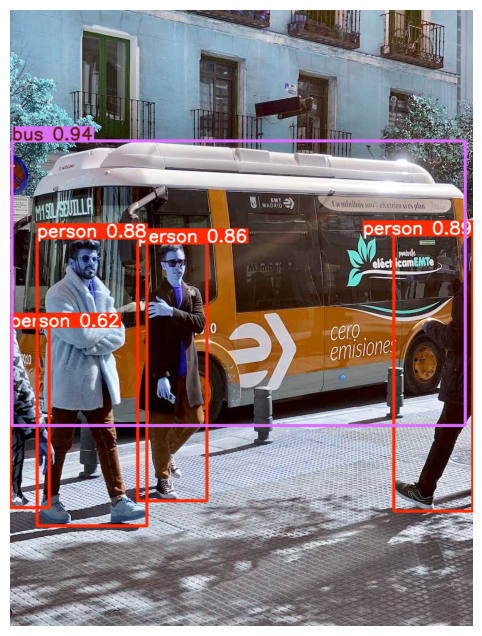

Toplam kişi: 4


In [29]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

model = YOLO("yolo11n.pt")

url = "https://ultralytics.com/images/bus.jpg"

response = requests.get(url)
img = Image.open(BytesIO(response.content))

results = model(img, conf=0.50)

annotated_img = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()


person_count = 0

for cls in results[0].boxes.cls:
    if model.names[int(cls)] == "person":
        person_count += 1

print("Toplam kişi:", person_count)